In [1]:
!git clone https://github.com/StrawHat564/df-rise-project.git /kaggle/working/df-rise-project

Cloning into '/kaggle/working/df-rise-project'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 36 (delta 15), reused 30 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 17.48 KiB | 5.83 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [3]:
# !cd df-rise-project && git pull

In [2]:
!ls df-rise-project

configs  notebooks  README.md  src


In [5]:
# !pip install diffusers transformers accelerate torchvision scikit-image

In [3]:
import torch, yaml, sys
REPO = "/kaggle/working/df-rise-project"   # <- your clone folder
sys.path.insert(0, REPO)

from src.pipeline import load_stable_diffusion_components, denoise_with_hooks, encode_prompt
from src.df_rise import df_rise_step
from src.visualization import plot_step_series, heatmap_overlay

cfg = yaml.safe_load(open(f"{REPO}/configs/default.yaml"))
components = load_stable_diffusion_components(cfg)   # downloads weights (~4GB first time)
print("Loaded:", list(components.keys()))

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

Loaded: ['tokenizer', 'text_encoder', 'vae', 'unet', 'scheduler']


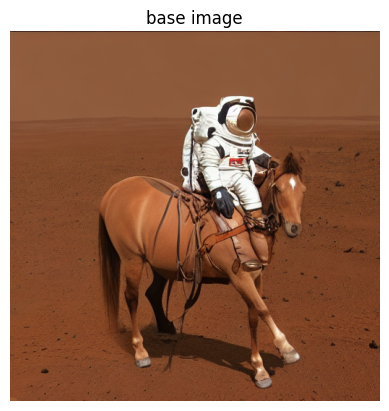

In [4]:
PROMPT = "a photograph of an astronaut riding a horse on mars"
img, info = denoise_with_hooks(components, PROMPT,
                               seed=cfg["model"]["seed"],
                               guidance_scale=cfg["model"]["guidance_scale"])
import matplotlib.pyplot as plt
plt.imshow(img); plt.axis('off'); plt.title("base image"); plt.show()

In [5]:
# note: df_rise_step signature is (unet, text_emb, latent, t, n_masks, seed, ...)
N = 30                      # low first; paper-scale is 100+. Bump once it runs.
emb = encode_prompt(components, PROMPT, "cuda")
timesteps = [int(t) for t in components["scheduler"].timesteps]
step_ids  = [0, 5, 10, 15, 20, len(timesteps)-1]     # early..late

saliency, ts = [], []
def hook(noise_pred, current, t, t_idx, prev):
    if t_idx in step_ids:
        print("latent:", current.dtype, "| emb:", emb.dtype, "| unet weights:", next(components["unet"].parameters()).dtype)
        S = df_rise_step(components["unet"], emb, current, int(t), n_masks=N, mask_threshold=cfg["dfrise"].get("mask_threshold"), seed=cfg["dfrise"].get("seed"))
        saliency.append(S.cpu().numpy()); ts.append(int(t))

denoise_with_hooks(components, PROMPT, seed=cfg["model"]["seed"],
                   guidance_scale=cfg["model"]["guidance_scale"], step_hook=hook)
print("analyzed steps:", ts)

latent: torch.float16 | emb: torch.float16 | unet weights: torch.float16
latent: torch.float16 | emb: torch.float16 | unet weights: torch.float16
latent: torch.float16 | emb: torch.float16 | unet weights: torch.float16
latent: torch.float16 | emb: torch.float16 | unet weights: torch.float16
latent: torch.float16 | emb: torch.float16 | unet weights: torch.float16
latent: torch.float16 | emb: torch.float16 | unet weights: torch.float16
analyzed steps: [958, 793, 628, 463, 298, 1]


AttributeError: module 'torchvision.transforms.functional' has no attribute 'interpolate'

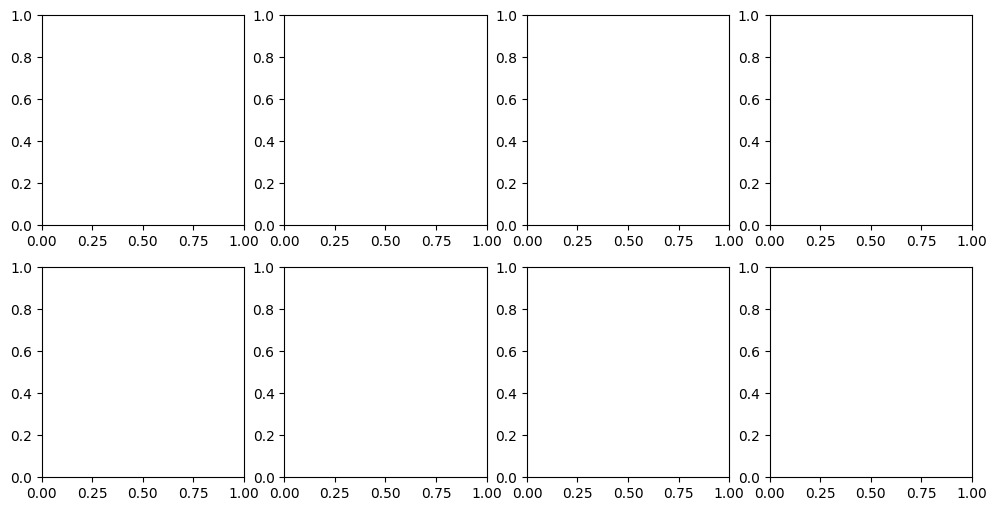

In [6]:
plot_step_series(saliency, ts, save_path=f"{REPO}/outputs/dfrise_steps.png")
plt.show()

over = heatmap_overlay(img, saliency[-1], alpha=0.5)
plt.imshow(over); plt.axis('off'); plt.title(f"DF-RISE overlay t={ts[-1]}"); plt.show()

maps: 6 | steps: [958, 793, 628, 463, 298, 1]
saliency value ranges per step:
  step 0 t=958: min=0.000 max=1.000 std=0.195 mean=0.505
  step 1 t=793: min=0.000 max=1.000 std=0.200 mean=0.475
  step 2 t=628: min=0.000 max=1.000 std=0.179 mean=0.456
  step 3 t=463: min=0.000 max=1.000 std=0.190 mean=0.439
  step 4 t=298: min=0.000 max=1.000 std=0.191 mean=0.465
  step 5 t=1: min=0.000 max=1.000 std=0.161 mean=0.301


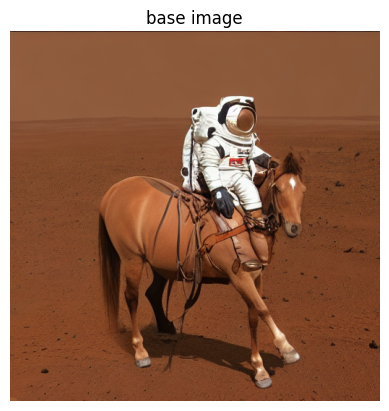

AttributeError: module 'torchvision.transforms.functional' has no attribute 'interpolate'

In [7]:
import numpy as np, matplotlib.pyplot as plt

# fix the original save bug (outputs/ dir was gitignored, missing on Kaggle)
import os; os.makedirs(f"{REPO}/outputs", exist_ok=True)

print("maps:", len(saliency), "| steps:", ts)
print("saliency value ranges per step:")
for i, (Sm, t) in enumerate(zip(saliency, ts)):
    print(f"  step {i} t={t}: min={Sm.min():.3f} max={Sm.max():.3f} std={Sm.std():.3f} mean={Sm.mean():.3f}")

# base image first — is IT correct?
plt.imshow(img); plt.axis('off'); plt.title("base image"); plt.show()

# overlay the LAST (lowest-t) map, which should be the meaningful one
over = heatmap_overlay(img, saliency[-1], alpha=0.5)
plt.imshow(over); plt.axis('off'); plt.title(f"DF-RISE overlay t={ts[-1]}"); plt.show()